In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [21]:
df = pd.read_csv('../lesson11/ecommerce_bigdata.csv')

label_encoder = {}
categorical_columns = ['Region', 'ProductCategory', 'CustomerType'] # Replace with your categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])
    label_encoder[col] = le # Store the label encoder for future use
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Encoded Region: {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory: {'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType: {'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [22]:
df.drop(['TransactionID','Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)
df.head()

,Sales,Profit,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,1,2,2
1,3283,944.32,0,2,1
2,4049,967.10,2,3,0
3,4331,434.57,3,4,0
4,3283,340.48,3,4,1


In [23]:
print('Classification Task: Predicting Customer Type based on transaction data'.center(30,'~'))

# Prepare X and Y
X_class = df.drop('CustomerType_Encoded', axis=1)
y_class = df['CustomerType_Encoded']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

Classification Task: Predicting Customer Type based on transaction data


In [24]:
classification_models = {
   ' Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
}

accuracies = []
classification_results = []
print("RESULTS".center(50,'='))


=====================RESULTS======================


Model:  Logistic Regression
Accuracy: 0.25
Precision: 0.17857142857142858
Recall: 0.25
F1: 0.20833333333333334
Confusion Matrix: [[ 0  2  8]
 [ 0  0 10]
 [ 2  8 10]]


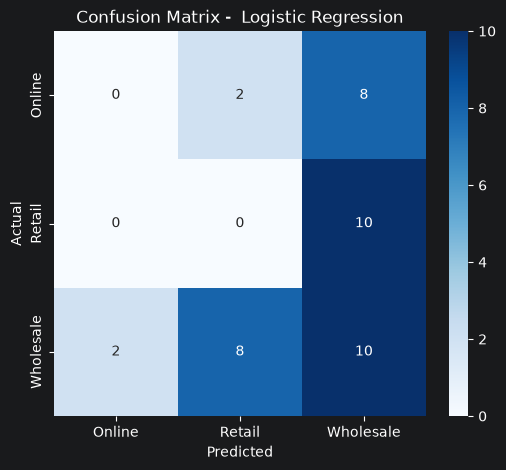

Model: Decision Tree Classifier
Accuracy: 0.225
Precision: 0.24551282051282053
Recall: 0.225
F1: 0.22666666666666666
Confusion Matrix: [[3 1 6]
 [5 2 3]
 [7 9 4]]


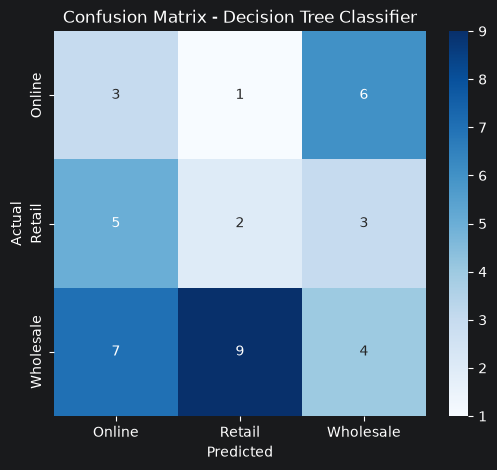

Model: Random Forest Classifier
Accuracy: 0.175
Precision: 0.19479638009049777
Recall: 0.175
F1: 0.17794612794612794
Confusion Matrix: [[ 2  2  6]
 [ 4  2  4]
 [ 4 13  3]]


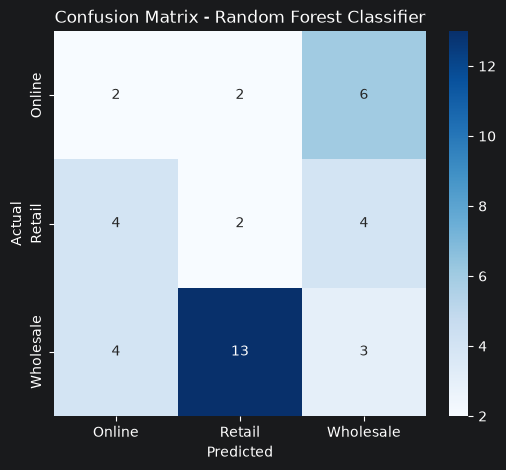

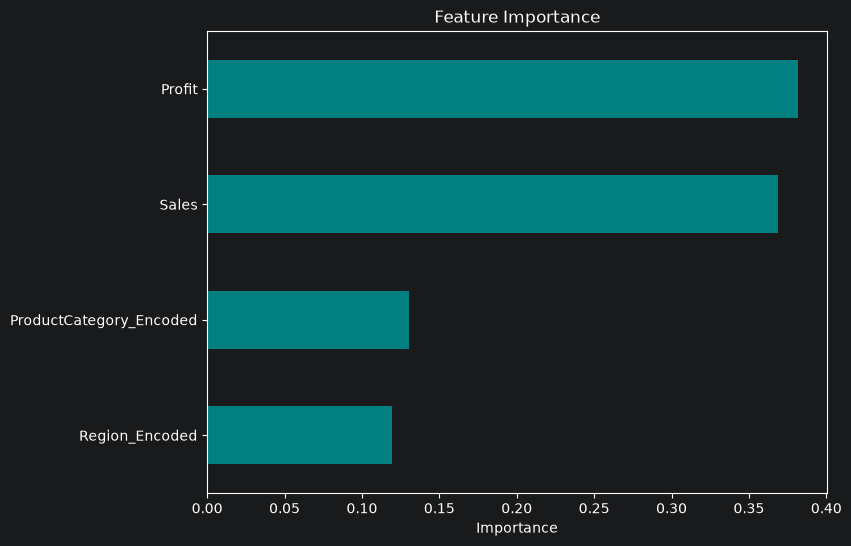

In [25]:
for name,model in classification_models.items():
    model.fit(X_train_class, y_train_class)
    y_pred = model.predict(X_test_class)

    # Metrics
    accuracy = accuracy_score(y_test_class, y_pred)
    precision = precision_score(y_test_class, y_pred, average='weighted')
    recall = recall_score(y_test_class, y_pred, average='weighted')
    f1 = f1_score(y_test_class, y_pred, average='weighted')
    cm = confusion_matrix(y_test_class, y_pred)

    accuracies.append(
        accuracy_score(y_test_class, y_pred)
    )

    classification_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_class, y_pred),
        'Precision': precision_score(y_test_class, y_pred, average='weighted'),
        'Recall': recall_score(y_test_class, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test_class, y_pred, average='weighted')
    })

    # Print Results
    print('='*50)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1: {f1}")
    print(f"Confusion Matrix: {cm}")

    # Heat Map
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_encoder['CustomerType'].classes_,
                yticklabels=label_encoder['CustomerType'].classes_)

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    if name == 'Random Forest Classifier':
        importance = pd.Series(
            model.feature_importances_,
            index=X_train_class.columns
        ).sort_values()

        plt.figure(figsize=(8,6))
        importance.plot(kind='barh', color='teal')

        plt.title('Feature Importance')
        plt.xlabel('Importance')
        plt.show()


C:\Users\HP PAVILION\AppData\Local\Temp\ipykernel_7524\3688013812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(classification_models.keys()),


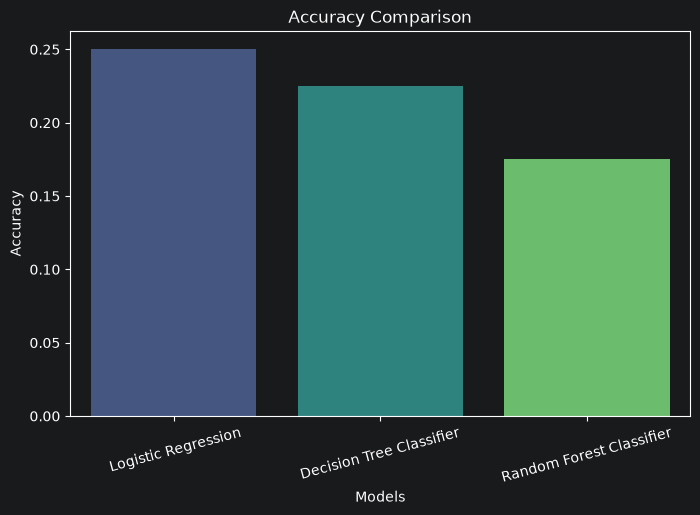

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(classification_models.keys()),
            y=accuracies,
            palette='viridis')

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.xticks(rotation=15)
plt.show()

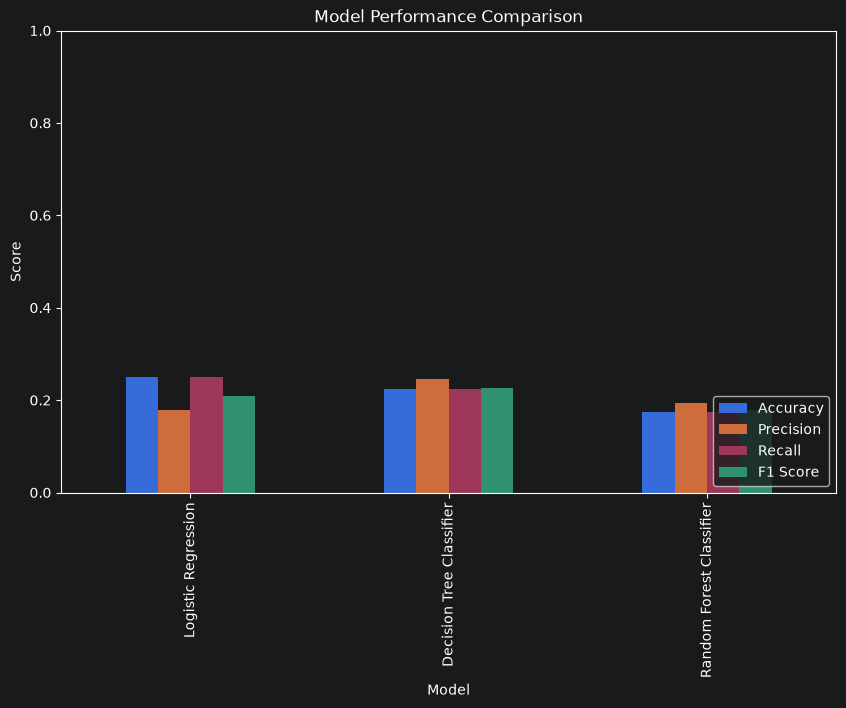

In [27]:
results_df = pd.DataFrame(classification_results)
results_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

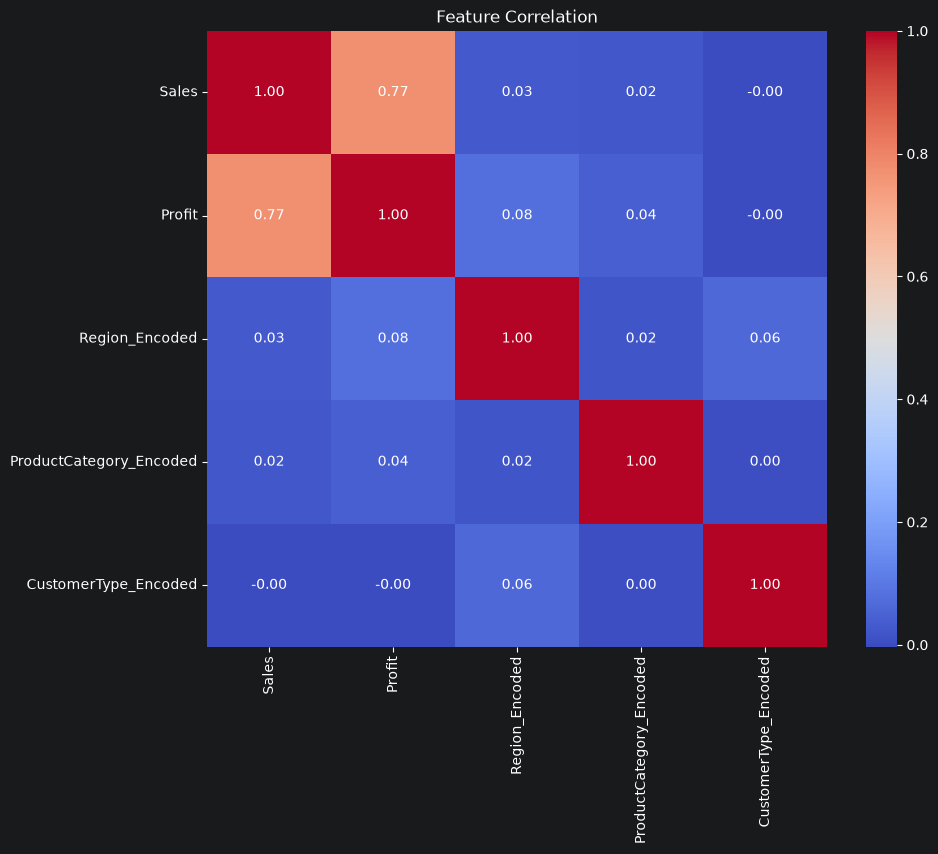

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Feature Correlation')
plt.show()